# Dislocation identification from orthogonal reconstructions

This notebook demonstrates a workflow to identify dislocations using orthogonal reconstructions.
Only the reconstructed **density** and **phase** are required as inputs.

Overview:
- Load orthogonal reconstruction
- Extract amplitude (density) and phase
- Compute dislocation signature from phase discontinuities and density features
- Visualise candidate dislocation locations

Notes: Keep the input reconstructions aligned and sampled consistently across axes.

## Load dataset

In [1]:
from matplotlib import rcParams   
# Plotting configurations
rcParams.update({
    #"font.family": "Liberation Serif",  # Use for titles, labels, and body text
    "font.size": 14,         # General font size
    "axes.labelsize": 14,    # X and Y labels font size
    "xtick.labelsize": 14,   # X-axis tick labels
    "ytick.labelsize": 14,   # Y-axis tick labels
    "legend.fontsize": 14,   # Legend font size
    "axes.titlesize": 14,    # Title font size
    # "savefig.bbox": "tight",
    'axes.linewidth': 2.0,   # axis box (spines)
    'grid.linewidth': 2.0,
    'grid.linestyle': 'dotted',
    'grid.alpha': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 0.5,
    'ytick.major.size': 0.5,
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',    
    'figure.dpi':150
})



In [2]:
from IPython.display import display
import numpy as np

import cdiutils
from cdiutils.utils import nan_to_zero, zero_to_nan,fill_up_support
from cdiutils.analysis import dislo

In [3]:
# path_to_data = "path/to/your/dataset.npy"
path_to_data = "C:\\Users\\aboud\\data\\S457_amp-phase_bulk.npz"
data = np.load(path_to_data)
density = data['amp']
phase = data['phase']
voxel_size = [float(i) for i in data['voxel_size']] # in nm

new_mask=(nan_to_zero(density)/np.nanmax(density)>0.05)
new_mask=fill_up_support(fill_up_support(new_mask))
density*=new_mask
phase*=new_mask
obj = density * np.exp(1j* phase)

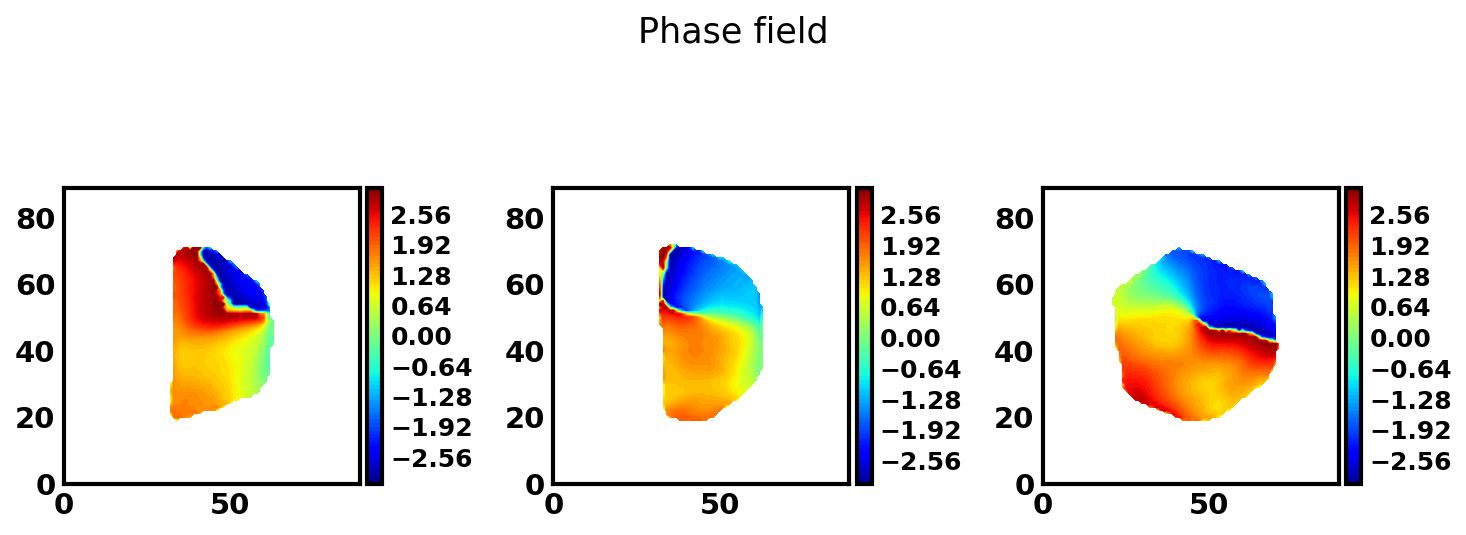

In [4]:
figure, axes=cdiutils.plot.plot_volume_slices(zero_to_nan(phase),plot_type='contourf',
                                title="Phase field", figsize=(10,4),label_size=12,
                                cmap='jet', 
                                vmin=-np.pi, vmax=np.pi);
# figure.savefig("original_phase.png")

## compute the minimum gradient of the phase field


In [5]:
support_strain,strain_min = dislo.map_min_gradient(obj=obj,
                                             voxel_size=voxel_size,
                                             save_filename_vti="dislo_fig/ortho_gradient_map.vti",
                                             plot_debug=False,
                                             path_to_save='',
                                             save_plot=False
                                             )

# apply a threshoold
stain_threshold = 0.35
strain_min[strain_min<0.3]=0

"amp" not in fieldnames, will save arrays without thresholding


## Analysis

### cleaning
here you can cut the segmented phase jump as there are noise espacilly near the surface and the orthogonalisation procesure.

The best is to compute this parametre before orthogonalisation then orthogonolise it. It is much better and cleaner

In [6]:
# use this plot and the vti to see if the clustering later works or no and adjust the parameters. 

# figure, axes=cdiutils.plot.plot_volume_slices(
#     zero_to_nan(phase)[:,:,40:],plot_type='contourf',
#     title="Phase field", figsize=(10,4),label_size=12,
#     cmap='jet',
#     vmin=-np.pi, vmax=np.pi
#     );

In [7]:
# strain_min[:35]=0
# strain_min[:,:35]=0
strain_min[:,:,:40]=0
# strain_min[60:]=0
# strain_min[:,55:]=0
# strain_min[:,:,55:]=0

### clusering the voxels that have a phase jump

In [8]:
final_labeled_clusters, num_final_clusters = dislo.clusters_dislo_strain_map(
    data=strain_min,
    amp=density,
    phase=phase,
    save_path='step1',
    voxel_sizes=tuple(voxel_size),
    threshold=stain_threshold,
    min_cluster_size=2,
    distance_threshold=2.0,
    cylinder_radius=1,
    num_spline_points=5000,
    smoothing_param=4,
    eps=2.5,
    min_samples=10,
    save_output=True,
    debug_plot=False)

dislo.save_to_vti(filename="dislo_fig/Step1.vti",
            voxel_size=tuple(voxel_size),
            tuple_array=(nan_to_zero(density),nan_to_zero(phase),final_labeled_clusters,strain_min),
            tuple_fieldnames=("density", "phase","dislo","strain"),amplitude_threshold=0.01,)

Number of clusters identified: 198
Filtered clusters: [  3  11  36  37  38  43  45  47  53  56  59  62  63  64  66  71  73  77
  83  84  85  86  88  89  96  99 107 112 113 114 115 116 121 129 130 131
 133 151 162 166 167 170 171 194 197]
Cylindrical mask constructed.
"amp" not in fieldnames, will save arrays without thresholding


### unify the clusters related to dislocation line and create a cylinder based on the cluster

In [9]:
threshold_dislo_cluster    = 0.5
unique_labels=np.unique(final_labeled_clusters)
print(unique_labels)
points = dislo.extract_structure(final_labeled_clusters, threshold_dislo_cluster)
# Fit a line to the extracted points
centroid, direction = dislo.fit_line_3d(points)
# Generate a filled cylinder in the same shape as the original volume
filled_cylinder_volume = dislo.generate_filled_cylinder(
    shape=final_labeled_clusters.shape,
    centroid=centroid, 
    direction=direction, 
    radius=1, 
    height=100, 
    step=1
    )
selected_dislocation_data=filled_cylinder_volume*new_mask


dislo.save_to_vti(filename="dislo_fig/Step2.vti",
            voxel_size=tuple(voxel_size),
            tuple_array=(nan_to_zero(density),nan_to_zero(phase),selected_dislocation_data,strain_min),
            tuple_fieldnames=("density", "phase","dislo","strain"),amplitude_threshold=0.01,)

[0 1 2]
"amp" not in fieldnames, will save arrays without thresholding


In [10]:
all_data_raw_and_ortho_dict=  {
                        'phase':phase, "obj":obj,"strain_min":strain_min,"dislo":selected_dislocation_data
}
# np.savez_compressed("step1_2_dislo",**all_data_raw_and_ortho_dict)

### plot phase around dislocation

In [11]:
radius_1                   = 7   # 1 -> 15 nm
dz                         = 2
dr                         = 2
selected_point_index       = 0
threshold_dislo_cluster    = 0.5

points = dislo.extract_structure(selected_dislocation_data, threshold_dislo_cluster) 
centroid, direction = dislo.fit_line_3d(points)

In [12]:
phase_ring_3d, angle_ring_3d, circular_mask,displacement_vectors,direction = dislo.plot_phase_around_dislo(
    density,
    phase, 
    selected_dislocation_data,
    radius_1, 
    dr, 
    centroid, 
    direction,slice_thickness=dz,
    voxel_sizes=voxel_size,
    selected_point_index=selected_point_index,
    save_vti=True,
    fig_title=None,
    save_path='dislo_fig/step3')
    

"amp" not in fieldnames, will save arrays without thresholding


In [13]:
phase_ring_3d = nan_to_zero(phase_ring_3d)

Raw angle : -179.03378 179.98021
Raw phase : -173.33815041665468 177.57626731266592
unwrapped phase : -207.252518913925 177.57626731266592


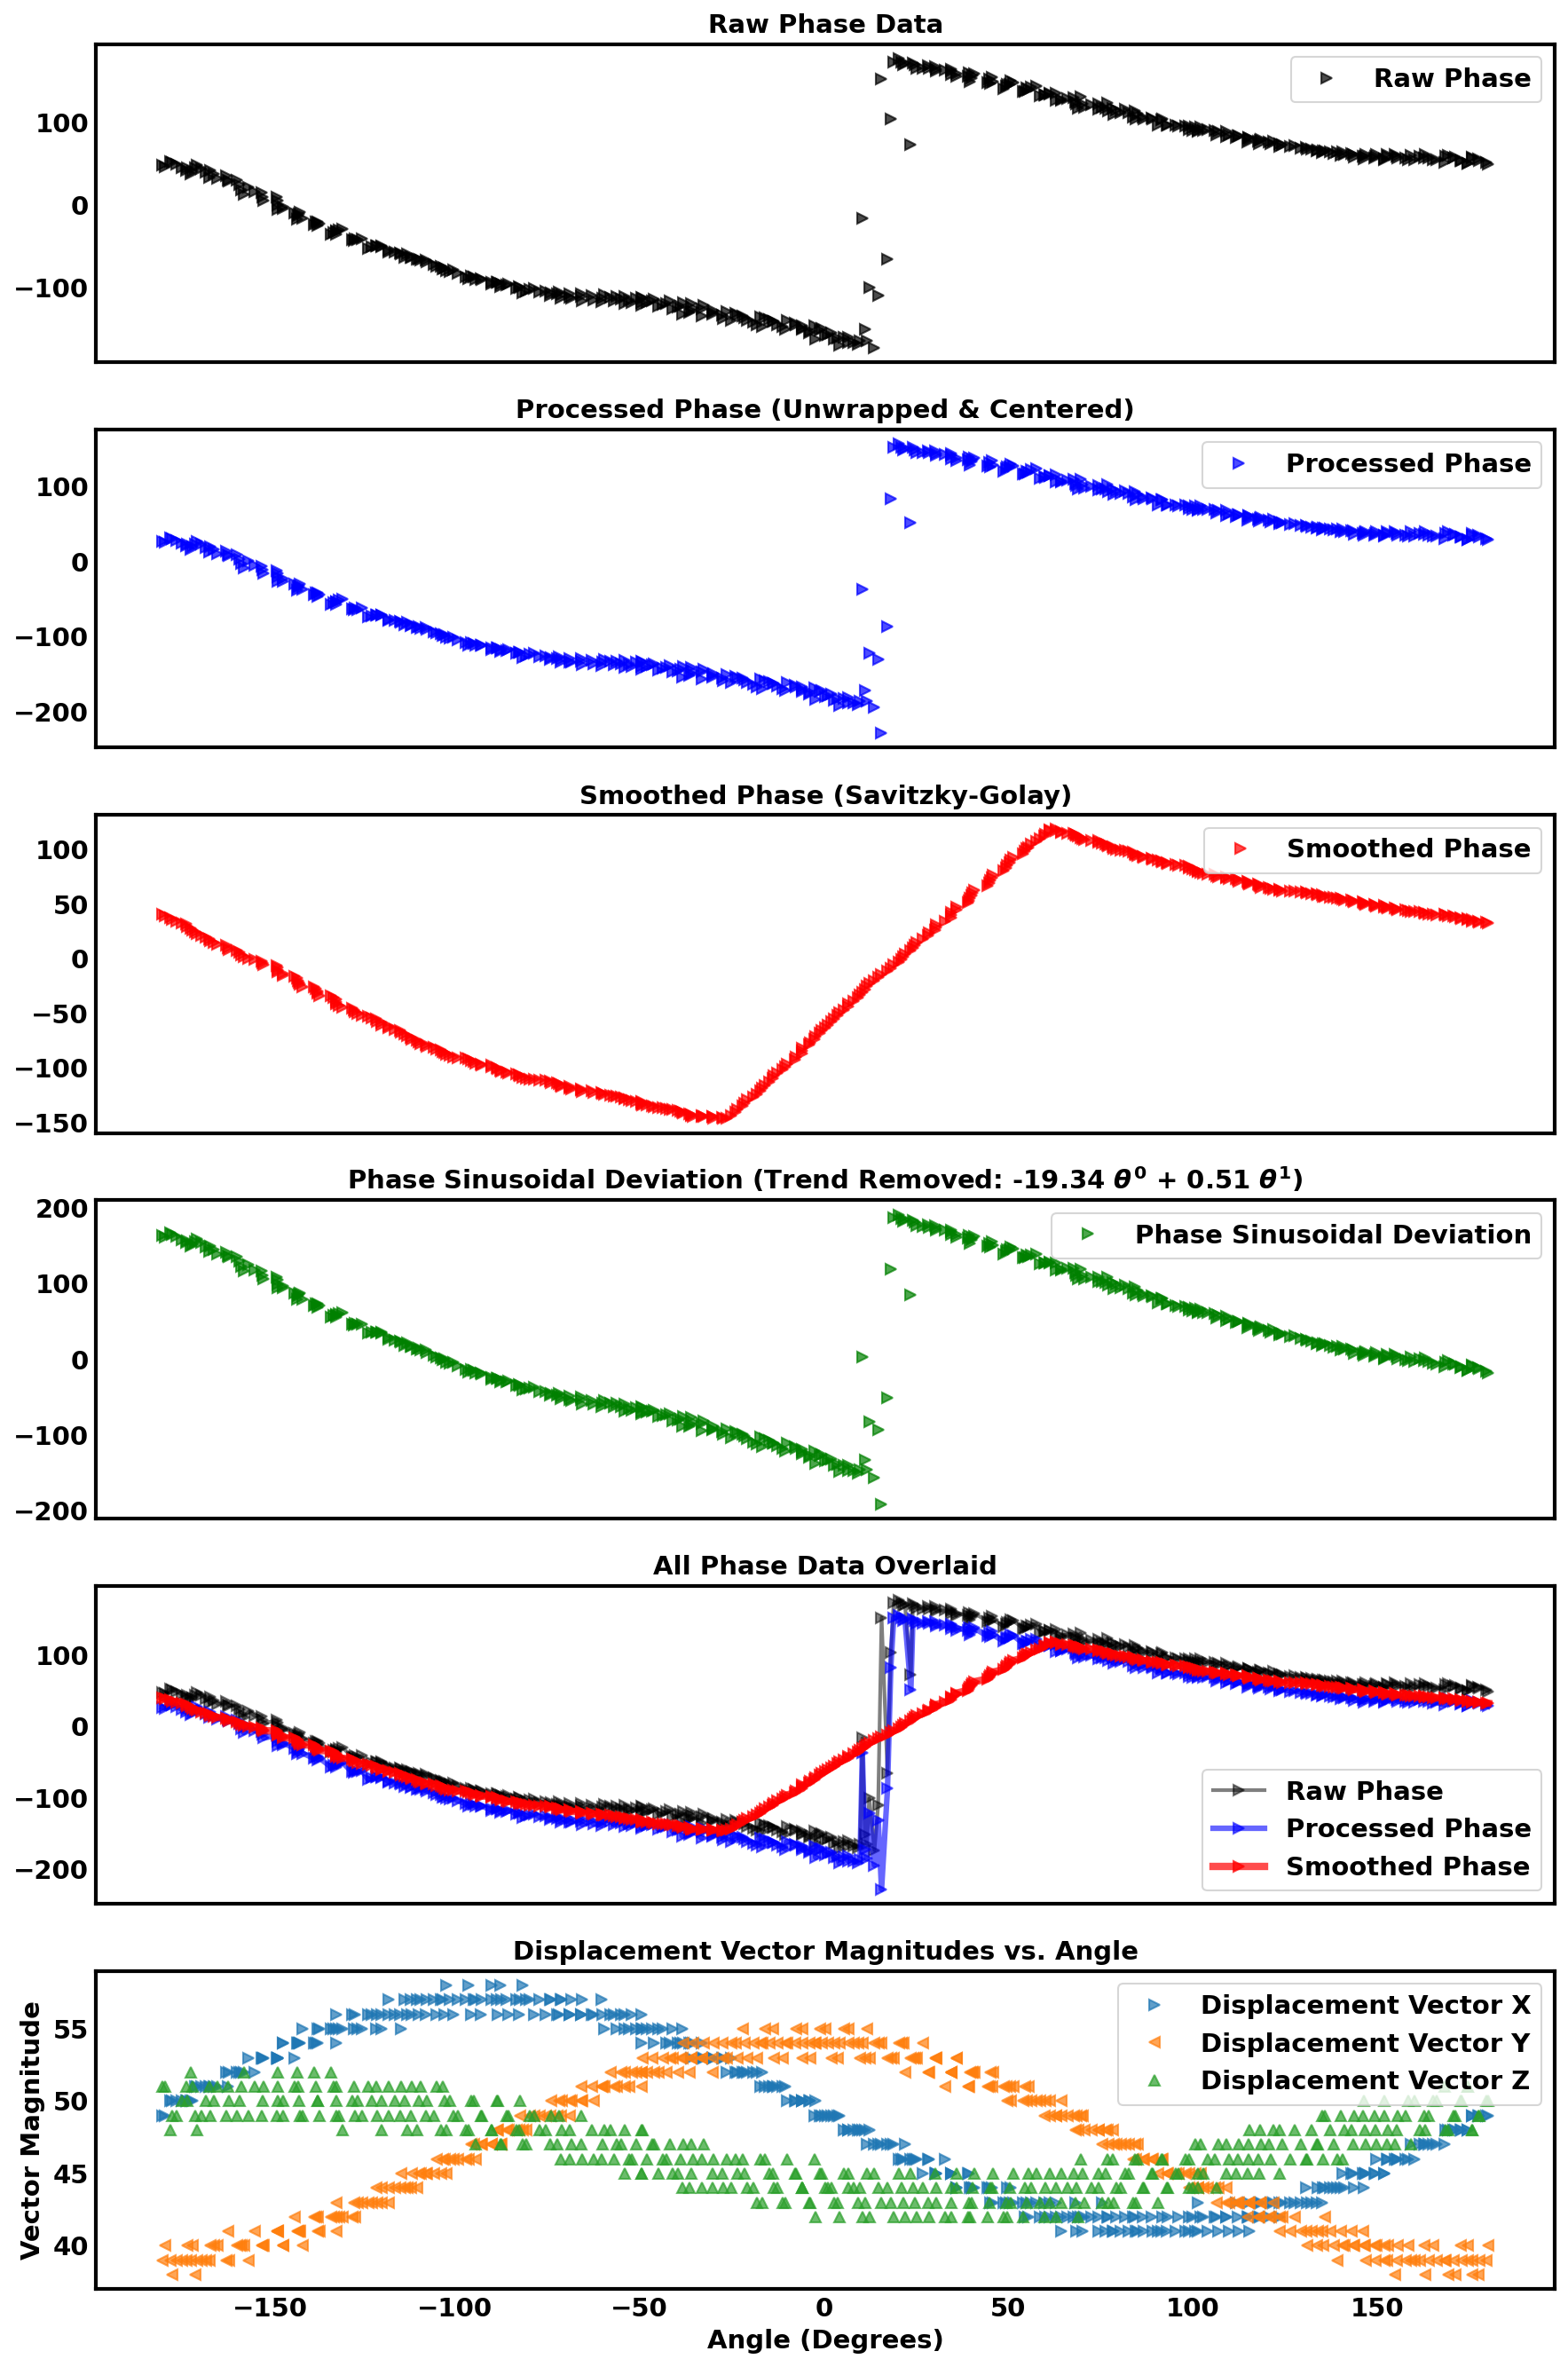

In [14]:
results___  =   dislo.dislo_process_phase_ring(
    angle_ring_3d,
    phase_ring_3d,
    displacement_vectors,
    factor_phase=+1.0,
    plot_debug=True,
    save_path='dislo_fig/step4.pdf')

### CLean data in the jump part

In [15]:
conditions = (
    # ( (phase_ring_3d-angle_ring_3d < 2.6) & (phase_ring_3d-angle_ring_3d >= -3.4) ) & 
    (angle_ring_3d < 0.5) & (angle_ring_3d > 0.15)
                 )
phase_ring_3d_clean = np.array(phase_ring_3d)
angle_ring_3d_clean = np.array(angle_ring_3d)
phase_ring_3d_clean[conditions]=0 
angle_ring_3d_clean[conditions]=0

Raw angle : -179.03378 179.98021
Raw phase : -170.80309139857778 168.1854889245317
unwrapped phase : -310.447982186113 52.9643627735973


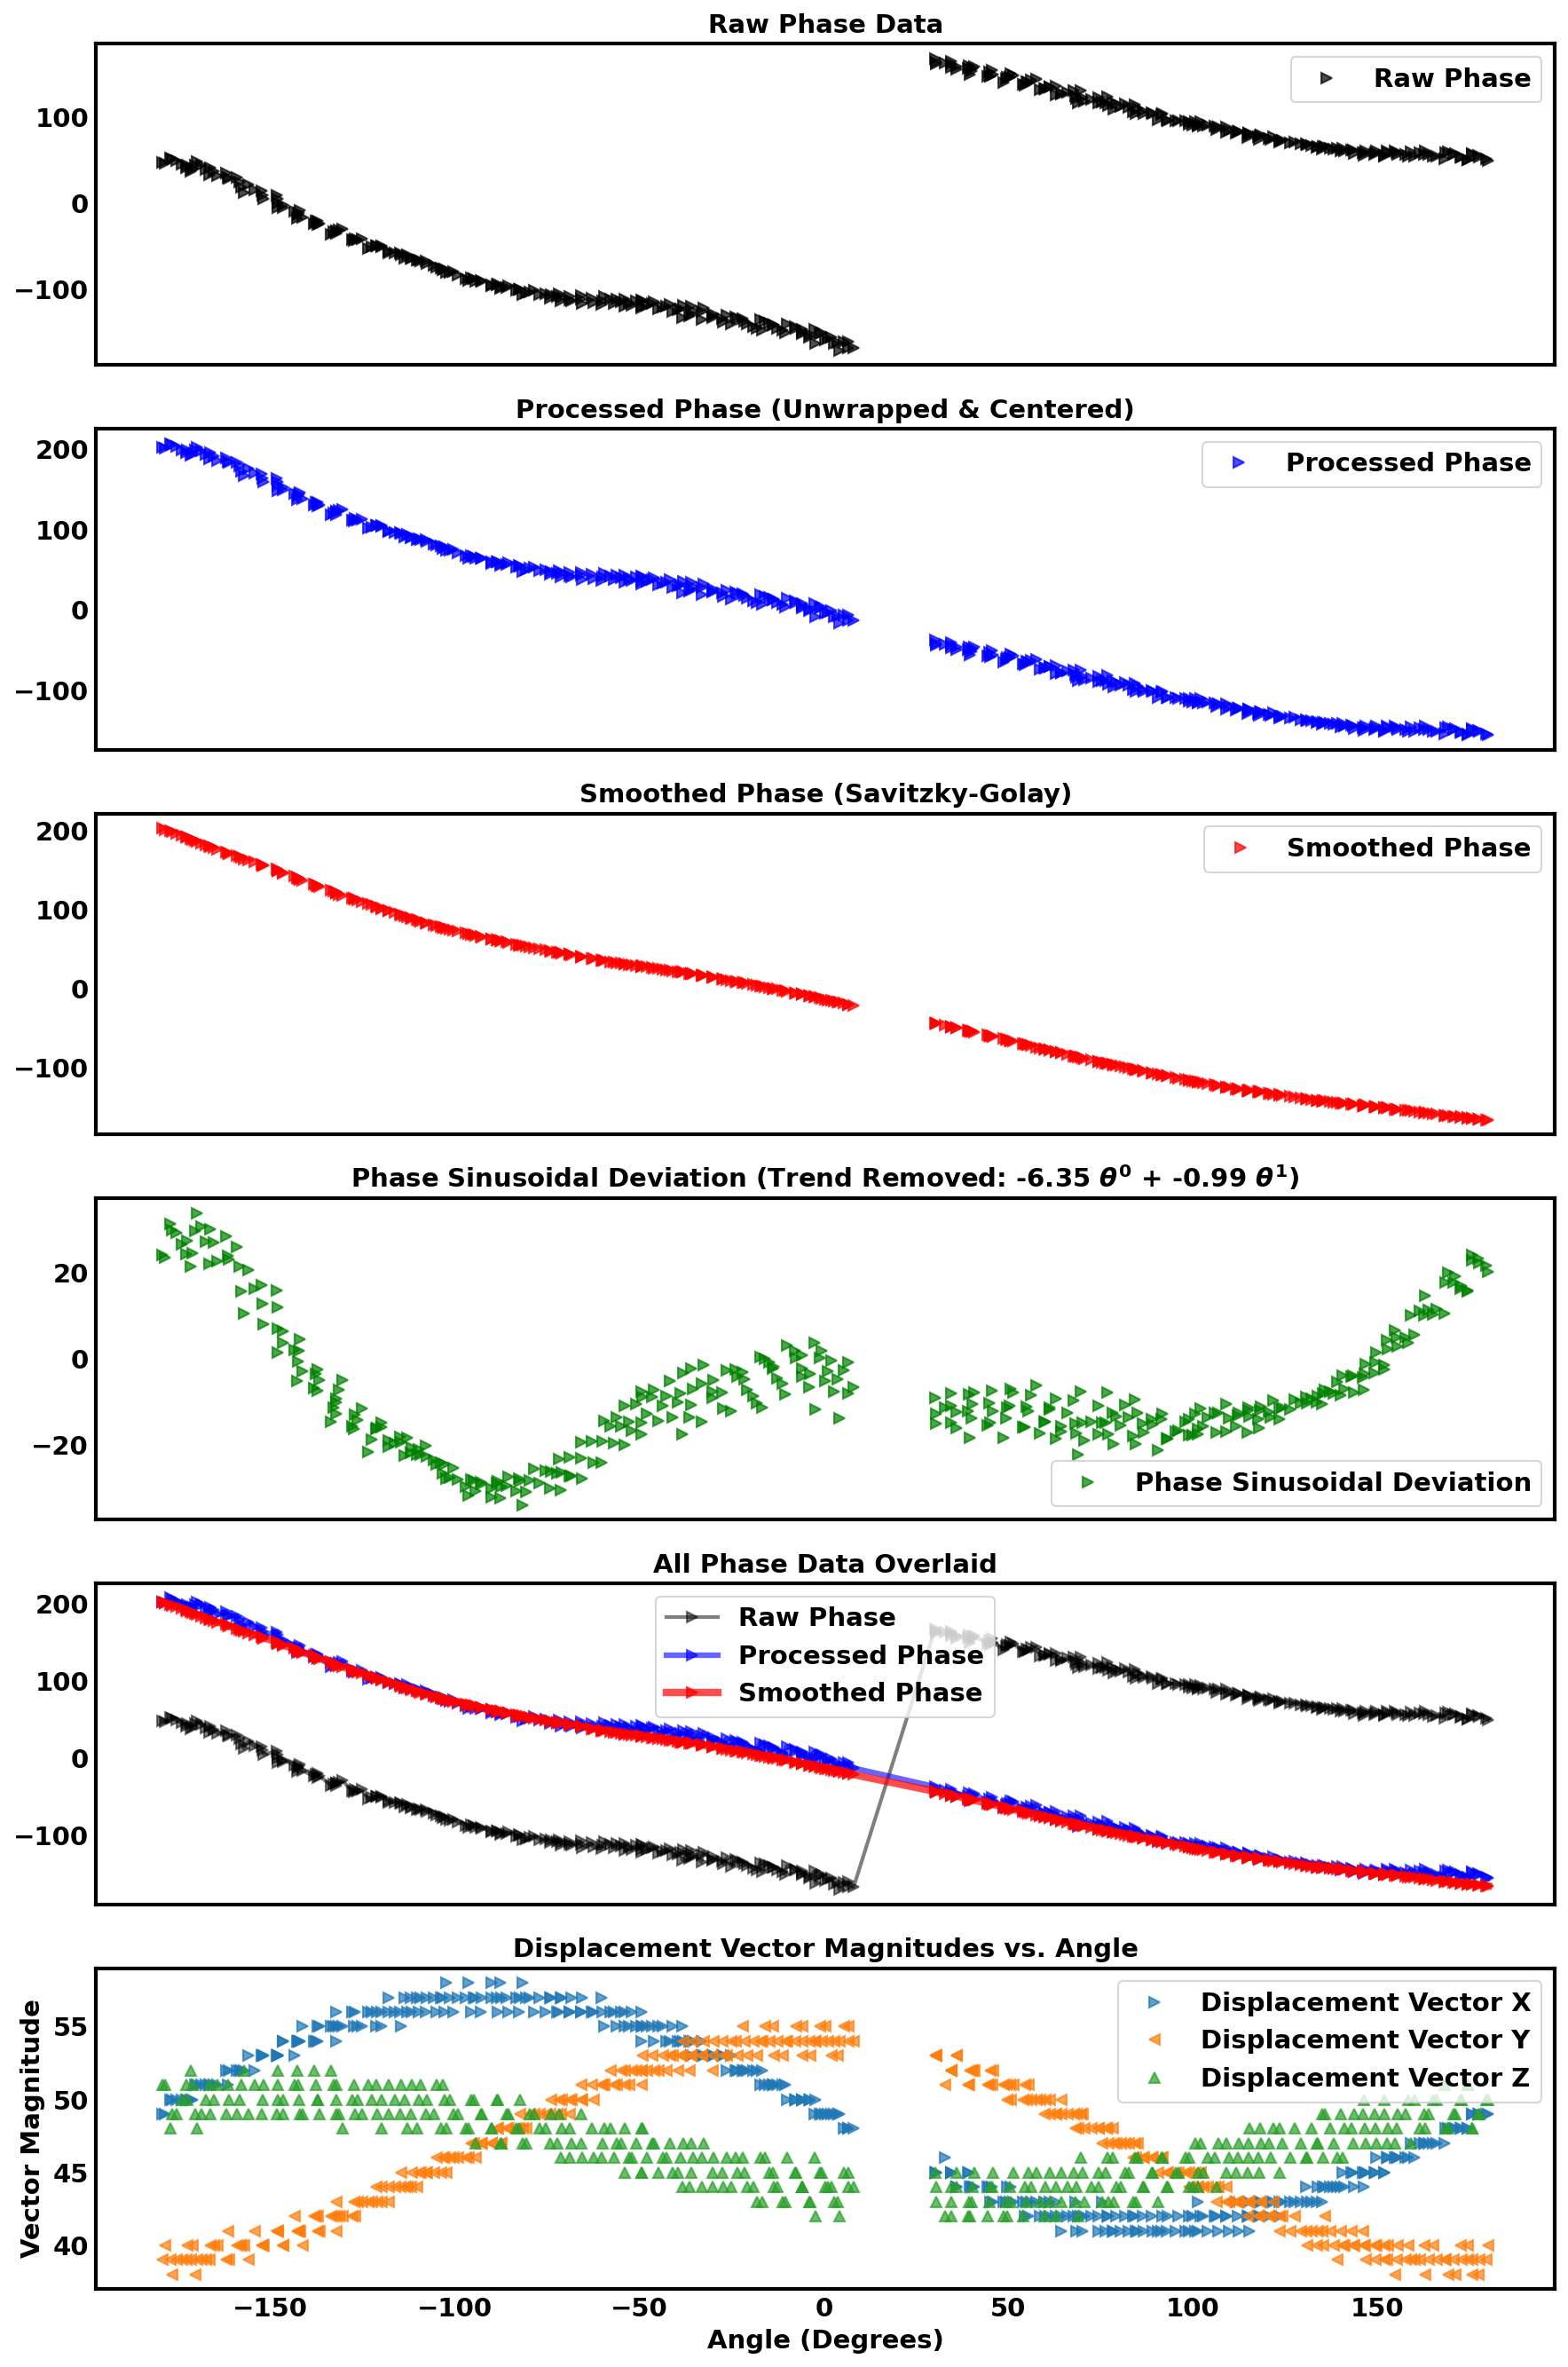

In [16]:
results___  =   dislo.dislo_process_phase_ring(
    angle_ring_3d_clean,
    phase_ring_3d_clean,
    displacement_vectors,
    factor_phase=-1.0,
    plot_debug=True,
    save_path='dislo_fig/step4beta.pdf')